In [ ]:
!pip install -q pycocoevalcap pycocotools nltk einops
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ Packages installed')

✅ Packages installed


In [ ]:
import os, json, math, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH  = '/content/drive/MyDrive/DeepLearning'
TRAIN_DIR   = os.path.join(DRIVE_PATH, 'train2014')
VAL_DIR     = os.path.join(DRIVE_PATH, 'val2014')
ANNOT_DIR   = os.path.join(DRIVE_PATH, 'annotations')
TRAIN_ANNOT = os.path.join(ANNOT_DIR, 'captions_train2014.json')
VAL_ANNOT   = os.path.join(ANNOT_DIR, 'captions_val2014.json')
CKPT_DIR    = os.path.join(DRIVE_PATH, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print('📁 Paths:')
for name, path in [('Train images',      TRAIN_DIR),
                   ('Val images',        VAL_DIR),
                   ('Train annotations', TRAIN_ANNOT),
                   ('Val annotations',   VAL_ANNOT)]:
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name}: {path}')

Mounted at /content/drive
📁 Paths:
  ✅ Train images: /content/drive/MyDrive/DeepLearning/train2014
  ✅ Val images: /content/drive/MyDrive/DeepLearning/val2014
  ✅ Train annotations: /content/drive/MyDrive/DeepLearning/annotations/captions_train2014.json
  ✅ Val annotations: /content/drive/MyDrive/DeepLearning/annotations/captions_val2014.json


In [ ]:
class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0:'<PAD>', 1:'<SOS>', 2:'<EOS>', 3:'<UNK>'}
        self.stoi = {v:k for k,v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return text.lower().strip().rstrip('.').split()

    def build(self, captions):
        counter = Counter()
        for cap in captions:
            counter.update(self.tokenize(cap))
        idx = 4
        for word, freq in sorted(counter.items()):
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1
        print(f'📖 Vocabulary: {len(self)} tokens')

    def encode(self, text, max_len=52):
        tokens = [self.SOS] + \
                 [self.stoi.get(w, self.UNK) for w in self.tokenize(text)][:max_len-2] + \
                 [self.EOS]
        return tokens

    def decode(self, indices):
        words = []
        for i in indices:
            if i == self.EOS: break
            if i not in (self.PAD, self.SOS):
                words.append(self.itos.get(i, '<UNK>'))
        return ' '.join(words)

with open(TRAIN_ANNOT) as f:
    train_data = json.load(f)

all_captions = [a['caption'] for a in train_data['annotations']]
vocab = Vocabulary(freq_threshold=5)
vocab.build(all_captions)
print(f'   Total captions: {len(all_captions):,}')

📖 Vocabulary: 9721 tokens
   Total captions: 414,113


In [ ]:
# ── Settings ─────────────────────────────────────────────────
IMG_SIZE    = 224
MAX_LEN     = 52
BATCH_SIZE  = 32
MAX_SAMPLES = 5_000   # ← small for quick test (~5 min total)
# ─────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class COCOCaptionDataset(Dataset):
    def __init__(self, img_dir, annot_path, vocab, transform, max_samples=None):
        with open(annot_path) as f:
            data = json.load(f)
        id2file = {img['id']: img['file_name'] for img in data['images']}
        annots  = data['annotations']
        if max_samples:
            annots = annots[:max_samples]
        self.samples = []
        for a in annots:
            fname = id2file.get(a['image_id'])
            fpath = os.path.join(img_dir, fname) if fname else None
            if fpath and os.path.exists(fpath):
                self.samples.append((fpath, a['caption']))
        self.vocab     = vocab
        self.transform = transform
        print(f'   Loaded: {len(self.samples):,} samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, caption = self.samples[idx]
        img = Image.open(fpath).convert('RGB')
        return self.transform(img), torch.tensor(
            self.vocab.encode(caption, MAX_LEN), dtype=torch.long)

def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    max_len = max(c.size(0) for c in caps)
    padded  = torch.zeros(len(caps), max_len, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :c.size(0)] = c
    return imgs, padded

print('Loading datasets...')
train_ds = COCOCaptionDataset(TRAIN_DIR, TRAIN_ANNOT, vocab,
                               train_transform, MAX_SAMPLES)
val_ds   = COCOCaptionDataset(VAL_DIR,   VAL_ANNOT,   vocab,
                               val_transform,   MAX_SAMPLES//5)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate_fn)

print(f'✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loading datasets...
   Loaded: 4,998 samples
   Loaded: 1,000 samples
✅ Train batches: 157 | Val batches: 32


In [ ]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, embed_dim=256, fine_tune=False):
        super().__init__()
        weights  = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = efficientnet_v2_s(weights=weights)
        self.features  = backbone.features
        self.proj = nn.Sequential(
            nn.Linear(1280, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, 49, embed_dim) * 0.02)
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, enable):
        for p in self.features.parameters():
            p.requires_grad = False
        if enable:
            for i in [6, 7]:
                for p in self.features[i].parameters():
                    p.requires_grad = True
            print('🔓 Fine-tuning: EfficientNet blocks 6-7 unlocked')
        else:
            print('🔒 Encoder frozen')

    def forward(self, x):
        feat = self.features(x)                   # (B, 1280, 7, 7)
        feat = feat.flatten(2).permute(0, 2, 1)  # (B, 49, 1280)
        feat = self.proj(feat)                    # (B, 49, embed_dim)
        return feat + self.pos_embed

print('EfficientNetEncoder defined ✅')

EfficientNetEncoder defined ✅


In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=6, ff_dim=1024, max_len=52, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos   = nn.Embedding(max_len, embed_dim)
        self.drop  = nn.Dropout(dropout)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.head.weight = self.embed.weight  # weight tying
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos.weight,   std=0.02)

    def forward(self, tgt_ids, memory, tgt_key_padding_mask=None):
        T   = tgt_ids.size(1)
        pos = torch.arange(T, device=tgt_ids.device).unsqueeze(0)
        x   = self.drop(self.embed(tgt_ids) + self.pos(pos))
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=x.device)
        out = self.transformer(
            x, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask)
        return self.head(self.norm(out))

print('TransformerDecoder defined ✅')

TransformerDecoder defined ✅


In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=6, ff_dim=1024, max_len=52, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos   = nn.Embedding(max_len, embed_dim)
        self.drop  = nn.Dropout(dropout)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.head.weight = self.embed.weight  # weight tying
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos.weight,   std=0.02)

    def forward(self, tgt_ids, memory, tgt_key_padding_mask=None):
        T   = tgt_ids.size(1)
        pos = torch.arange(T, device=tgt_ids.device).unsqueeze(0)
        x   = self.drop(self.embed(tgt_ids) + self.pos(pos))
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=x.device)
        out = self.transformer(
            x, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask)
        return self.head(self.norm(out))

print('TransformerDecoder defined ✅')

TransformerDecoder defined ✅


In [ ]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=6, ff_dim=1024, max_len=52, dropout=0.1):
        super().__init__()
        self.encoder = EfficientNetEncoder(embed_dim=embed_dim)
        self.decoder = TransformerDecoder(
            vocab_size, embed_dim, num_heads,
            num_layers, ff_dim, max_len, dropout)

    def forward(self, images, captions):
        memory   = self.encoder(images)
        tgt      = captions[:, :-1]
        pad_mask = (tgt == 0)
        return self.decoder(tgt, memory, pad_mask)

    @torch.no_grad()
    def generate_greedy(self, image, max_len=30):
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(DEVICE))
        tokens = [vocab.SOS]
        for _ in range(max_len):
            tgt     = torch.tensor([tokens], device=DEVICE)
            next_id = self.decoder(tgt, memory)[0, -1].argmax().item()
            if next_id == vocab.EOS: break
            tokens.append(next_id)
        return vocab.decode(tokens[1:])

    @torch.no_grad()
    def generate_beam(self, image, beam_size=5, max_len=30):
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(DEVICE))
        beams, completed = [(0.0, [vocab.SOS])], []
        for _ in range(max_len):
            candidates = []
            for score, seq in beams:
                if seq[-1] == vocab.EOS:
                    completed.append((score, seq))
                    continue
                tgt      = torch.tensor([seq], device=DEVICE)
                log_prob = F.log_softmax(
                    self.decoder(tgt, memory)[0, -1], dim=-1)
                for lp, idx in zip(*log_prob.topk(beam_size)):
                    candidates.append((score + lp.item(), seq + [idx.item()]))
            if not candidates: break
            candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
            beams = candidates[:beam_size]
        best = max(completed + beams,
                   key=lambda x: x[0] / max(len(x[1]), 1))
        return vocab.decode(best[1][1:])

model = ImageCaptioningModel(
    vocab_size=len(vocab), embed_dim=256, num_heads=8,
    num_layers=6, ff_dim=1024, max_len=MAX_LEN, dropout=0.1
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n🏗️  Model ready on {DEVICE}')
print(f'   Total parameters:     {total:,}')
print(f'   Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 179MB/s]


🔒 Encoder frozen

🏗️  Model ready on cuda
   Total parameters:     29,351,241
   Trainable parameters: 9,173,753


In [ ]:
def get_optimizer_and_scheduler(model, phase, steps_per_epoch):
    # ── Quick test: 2 + 3 epochs ─────────────────────────────
    lr, epochs = (3e-4, 2) if phase == 1 else (1e-4, 3)
    # ── Full run (uncomment when ready): ─────────────────────
    # lr, epochs = (3e-4, 8) if phase == 1 else (1e-4, 20)
    # ─────────────────────────────────────────────────────────
    params       = [p for p in model.parameters() if p.requires_grad]
    optimizer    = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    total_steps  = epochs * steps_per_epoch
    warmup_steps = steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return scheduler, optimizer, epochs


criterion = nn.CrossEntropyLoss(ignore_index=vocab.PAD, label_smoothing=0.1)


def run_epoch(model, loader, optimizer, scheduler, is_train):
    model.train() if is_train else model.eval()
    total_loss = total_tok = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, caps in loader:
            imgs, caps  = imgs.to(DEVICE), caps.to(DEVICE)
            logits      = model(imgs, caps)
            targets     = caps[:, 1:]
            B, T, V     = logits.shape
            loss        = criterion(logits.reshape(B*T, V), targets.reshape(B*T))
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            mask        = (targets != vocab.PAD)
            total_loss += loss.item() * mask.sum().item()
            total_tok  += mask.sum().item()
    avg = total_loss / total_tok
    return avg, math.exp(min(avg, 20))


def train_phase(model, phase, train_loader, val_loader):
    print(f'\n{"="*55}')
    print(f'  PHASE {phase} TRAINING')
    print(f'{"="*55}')
    scheduler, optimizer, n_epochs = get_optimizer_and_scheduler(
        model, phase, len(train_loader))
    best_val, history = float('inf'), []
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_ppl = run_epoch(model, train_loader, optimizer, scheduler, True)
        va_loss, va_ppl = run_epoch(model, val_loader,   optimizer, scheduler, False)
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': tr_loss,
                        'val_loss': va_loss, 'train_ppl': tr_ppl,
                        'val_ppl': va_ppl})
        print(f'Ep {epoch:02d}/{n_epochs} | '
              f'Train {tr_loss:.4f} (PPL {tr_ppl:.1f}) | '
              f'Val {va_loss:.4f} (PPL {va_ppl:.1f}) | '
              f'{elapsed:.0f}s')
        if va_loss < best_val:
            best_val = va_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'val_loss': va_loss},
                       os.path.join(CKPT_DIR, f'best_phase{phase}.pt'))
            print(f'   💾 Saved (val_loss={va_loss:.4f})')
    return history


# ── Phase 1: frozen encoder ───────────────────────────────────
history_p1 = train_phase(model, 1, train_loader, val_loader)

# ── Phase 2: fine-tune encoder ────────────────────────────────
model.encoder.set_fine_tune(enable=True)
history_p2 = train_phase(model, 2, train_loader, val_loader)


  PHASE 1 TRAINING
Ep 01/2 | Train 6.9589 (PPL 1052.5) | Val 5.5548 (PPL 258.5) | 257s
   💾 Saved (val_loss=5.5548)
Ep 02/2 | Train 4.9494 (PPL 141.1) | Val 5.2367 (PPL 188.0) | 87s
   💾 Saved (val_loss=5.2367)
🔓 Fine-tuning: EfficientNet blocks 6-7 unlocked

  PHASE 2 TRAINING
Ep 01/3 | Train 4.7586 (PPL 116.6) | Val 5.1684 (PPL 175.6) | 92s
   💾 Saved (val_loss=5.1684)
Ep 02/3 | Train 4.6226 (PPL 101.8) | Val 5.0608 (PPL 157.7) | 93s
   💾 Saved (val_loss=5.0608)
Ep 03/3 | Train 4.5148 (PPL 91.4) | Val 5.0407 (PPL 154.6) | 92s
   💾 Saved (val_loss=5.0407)


✅ Loaded checkpoint (val_loss=5.0407)


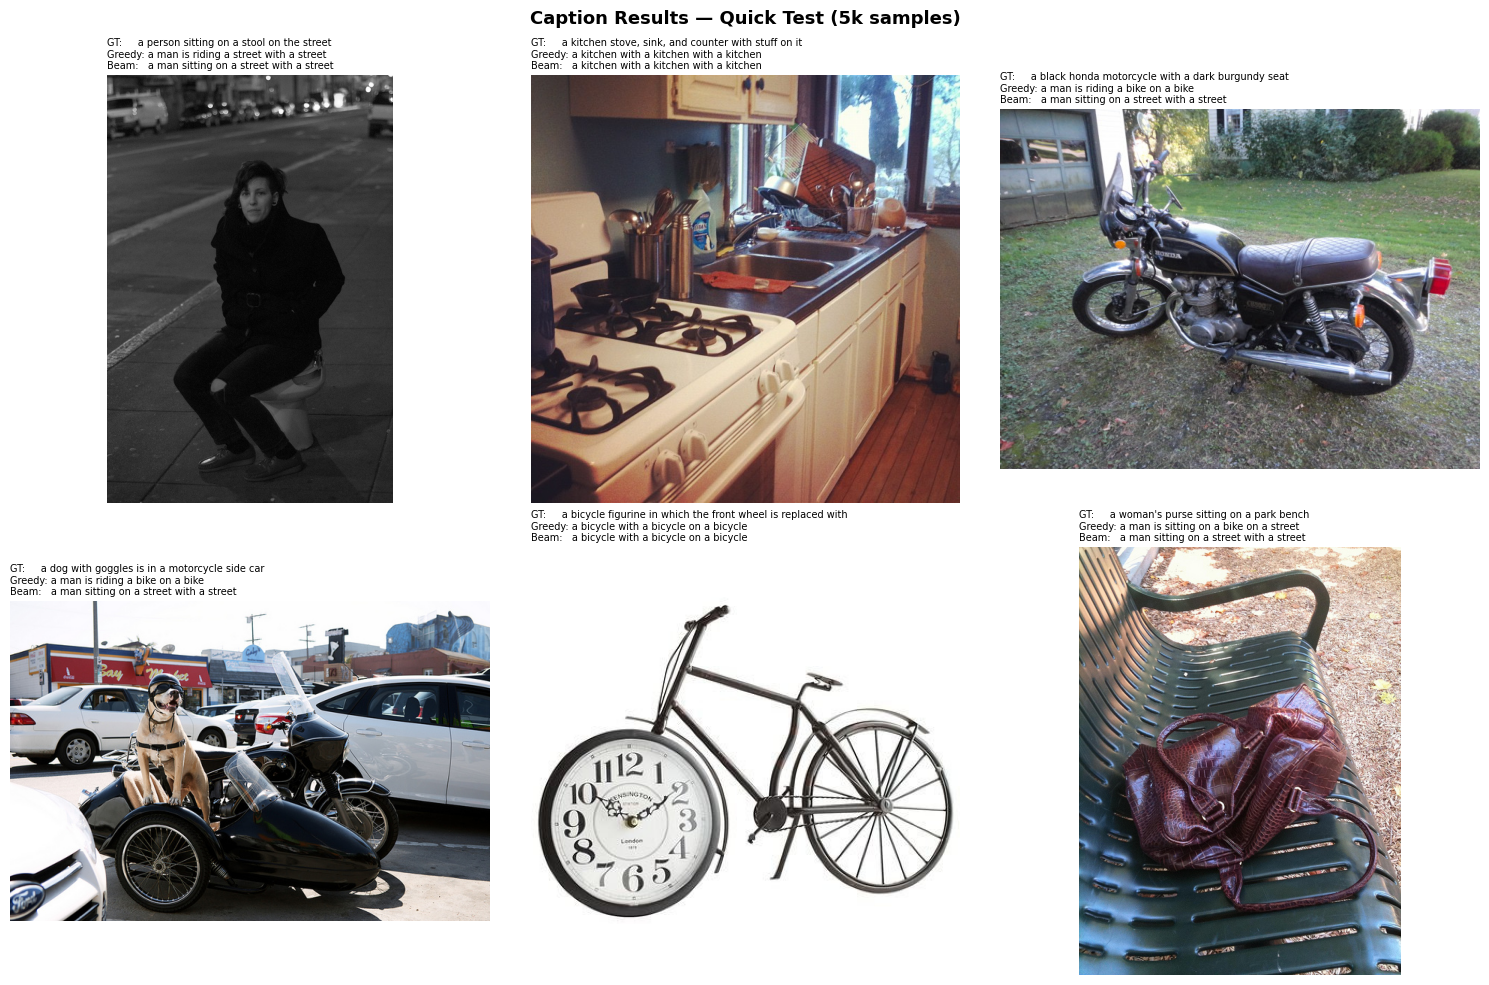

In [ ]:
# Load best checkpoint
ckpt = torch.load(os.path.join(CKPT_DIR, 'best_phase2.pt'), map_location=DEVICE)
model.load_state_dict(ckpt['model'])
print(f'✅ Loaded checkpoint (val_loss={ckpt["val_loss"]:.4f})')

# Test on 6 random validation images
model.eval()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

indices = random.sample(range(len(val_ds)), 6)

for ax, idx in zip(axes, indices):
    img_tensor, gt_ids = val_ds[idx]
    fpath = val_ds.samples[idx][0]

    # Generate captions
    greedy = model.generate_greedy(img_tensor)
    beam   = model.generate_beam(img_tensor, beam_size=5)
    gt     = vocab.decode(gt_ids.tolist())

    # Show image
    orig = Image.open(fpath).convert('RGB')
    ax.imshow(orig)
    ax.axis('off')
    ax.set_title(
        f'GT:     {gt[:60]}\n'
        f'Greedy: {greedy[:60]}\n'
        f'Beam:   {beam[:60]}',
        fontsize=7, loc='left', pad=4
    )

plt.suptitle('Caption Results — Quick Test (5k samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'quick_test_results.png'), dpi=120)
plt.show()

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

model.eval()
refs_all, hyps_all = [], []

with torch.no_grad():
    for idx in range(min(200, len(val_ds))):
        img_tensor, gt_ids = val_ds[idx]
        pred = model.generate_beam(img_tensor, beam_size=5)
        ref  = vocab.decode(gt_ids.tolist())
        refs_all.append([ref.split()])
        hyps_all.append(pred.split())

sf    = SmoothingFunction().method4
bleu1 = corpus_bleu(refs_all, hyps_all, weights=(1,0,0,0), smoothing_function=sf)
bleu4 = corpus_bleu(refs_all, hyps_all, weights=(.25,.25,.25,.25), smoothing_function=sf)

print(f'📊 Results on 200 val samples (5k training):')
print(f'   BLEU-1: {bleu1*100:.2f}')
print(f'   BLEU-4: {bleu4*100:.2f}')
print(f'\n⚠️  Low scores expected — only 5k samples trained')
print(f'   With 100k samples expect BLEU-1 ~55-65, BLEU-4 ~12-18')

📊 Results on 200 val samples (5k training):
   BLEU-1: 29.76
   BLEU-4: 4.34

⚠️  Low scores expected — only 5k samples trained
   With 100k samples expect BLEU-1 ~55-65, BLEU-4 ~12-18


Ground Truth : a bicycle replica with a clock as the front wheel
Greedy       : a bicycle with a bicycle on a bicycle
Beam Search  : a bicycle with a bicycle on a bicycle


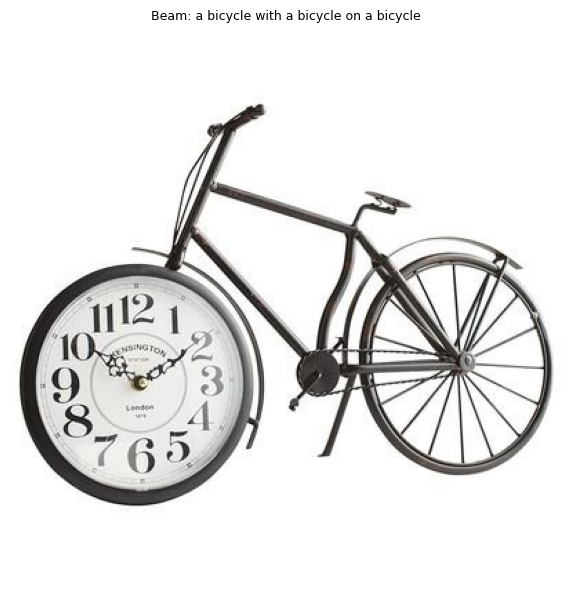

In [ ]:
# Test on ONE specific image interactively
idx = 0  # ← change this number to see different images

img_tensor, gt_ids = val_ds[idx]
fpath = val_ds.samples[idx][0]

greedy = model.generate_greedy(img_tensor)
beam   = model.generate_beam(img_tensor, beam_size=5)
gt     = vocab.decode(gt_ids.tolist())

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(Image.open(fpath).convert('RGB'))
ax.axis('off')
print(f'Ground Truth : {gt}')
print(f'Greedy       : {greedy}')
print(f'Beam Search  : {beam}')
plt.title(f'Beam: {beam}', fontsize=9, wrap=True)
plt.tight_layout()
plt.show()